# Session 4-->5: Heart Rate Analysis [USING FINDPEAKS]

In [1]:
# Load absorption data from CSV file
# Skip header and convert values to float

In [2]:
# Extract time and pulse values

In [3]:
time = []
absorption = []

In [4]:
# Extract time and pulse values

In [5]:
with open('data/pulse_data.csv', 'r') as f:
    next(f)  # skip header
    
    for line in f:
        t, p = line.strip().split(',')
        time.append(float(t))
        absorption.append(float(p))

In [6]:
# Load pulse data from csv file

In [7]:
from matplotlib import pyplot as plt

In [8]:
# Plot pulse data over time using matplotlib

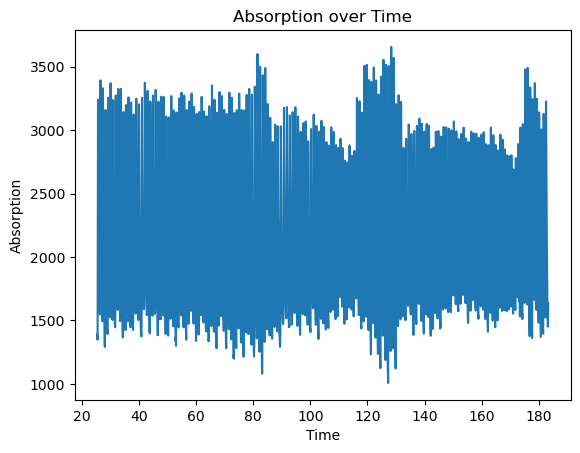

In [9]:
plt.plot(time, absorption)
plt.xlabel("Time")
plt.ylabel("Absorption")
plt.title("Absorption over Time")
plt.show()

In [10]:
# Peak Detection

# A peak is defined as a point that is higher than its neighboring values.

# These peaks correspond to heart beats.

In [11]:
peaks = []

for i in range(1, len(absorption)-1):
    if absorption[i] > absorption[i-1] and absorption[i] > absorption[i+1]:
        if len(peaks) == 0 or (time[i] - peaks[-1]) > 0.5:
            peaks.append(time[i])

In [12]:
print(len(peaks))

151


In [13]:
# Time Difference Between Peaks

# We compute the time difference between consecutive peaks.

In [14]:
delta_t = []

for i in range(1, len(peaks)):
    diff = peaks[i] - peaks[i-1]
    delta_t.append(diff)

In [15]:
# Heart Rate Calculation

#The heart rate is calculated using:

# H = 60 / ΔT

# where ΔT is the time between peaks.

In [16]:
heart_rate = []

for dt in delta_t:
    hr = 60 / dt
    heart_rate.append(hr)

In [17]:
# Heart Rate Plot

# We plot the heart rate over time.

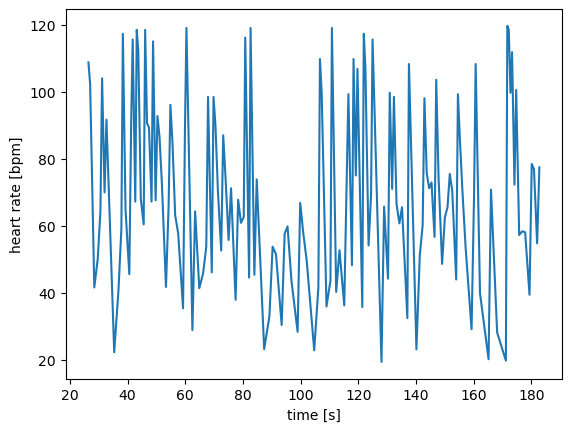

In [18]:
plt.plot(peaks[1:], heart_rate)
plt.xlabel("time [s]")
plt.ylabel("heart rate [bpm]")
plt.show()

In [ ]:
# Using Pandas and importing libraries

In [9]:
import numpy as np
import pandas as pd

time = pd.Series(np.linspace(0, 60, 500))
absorption = pd.Series(np.sin(time) + np.random.normal(0, 0.2, 500))

In [10]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [11]:
# Generating synthetic pulse signal (SORRY LOST MY PULSE DATA FILE, AND I DON'T REMEMBER)
time = pd.Series(np.linspace(0, 60, 500))  # 60 seconds
absorption = pd.Series(np.sin(time) + np.random.normal(0, 0.2, 500))

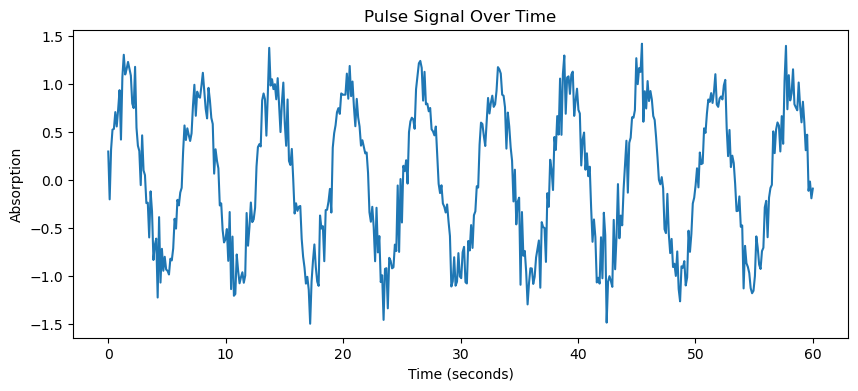

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(time, absorption)
plt.title("Pulse Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Absorption")
plt.show()

In [13]:
peaks, _ = find_peaks(absorption, distance=10)

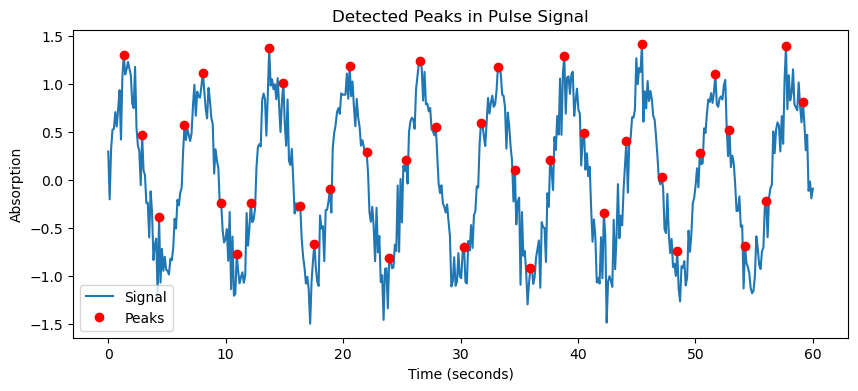

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(time, absorption, label="Signal")
plt.plot(time[peaks], absorption[peaks], "ro", label="Peaks")
plt.title("Detected Peaks in Pulse Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Absorption")
plt.legend()
plt.show()

In [15]:
#Calculating Heart Rate
duration = time.iloc[-1] - time.iloc[0]  # total time in seconds
heart_rate = (len(peaks) / duration) * 60  # beats per minute

heart_rate

39.0

In [16]:
#Interpretation
print(f"Estimated Heart Rate: {heart_rate:.2f} beats per minute (BPM)")

Estimated Heart Rate: 39.00 beats per minute (BPM)


In [17]:
#Improving Peak Detection
peaks, _ = find_peaks(absorption, distance=10, height=0)

In [ ]:
#Conclusion: This analysis demonstrates how physiological signals can be processed using Pandas and signal processing techniques to estimate heart rate from peak detection.